# Dataset Cleaning Process
Following the exact same cleaning steps as in main.ipynb:
1. Drop constant columns (84 -> 72 features)
2. Drop highly correlated (72 -> 57 features)
3. Drop network identifiers (57 -> 52 features)
4. Create 20-feature version from cleaned data

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import gc
from tqdm import tqdm

# Load datasets
folder_path = os.path.join('..', 'datasets')
filenames = ['metasploitable-2.csv', 'Normal_data.csv', 'OVS.csv']

# Load and combine datasets
dfs = []
for name in filenames:
    file_path = os.path.join(folder_path, name)
    df = pd.read_csv(file_path)
    print(f"Loaded {name} with shape {df.shape}")
    dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")

Loaded metasploitable-2.csv with shape (136743, 84)
Loaded Normal_data.csv with shape (68424, 84)
Loaded Normal_data.csv with shape (68424, 84)
Loaded OVS.csv with shape (138722, 84)

Combined shape: (343889, 84)
Loaded OVS.csv with shape (138722, 84)

Combined shape: (343889, 84)


In [9]:
# Step 1: Drop constant columns (84 -> 72)
constant_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 1]
df_cleaned = df_raw.drop(columns=constant_columns)
print(f"After dropping constant columns: {df_cleaned.shape}")

# Step 2: Drop highly correlated features (72 -> 57)
corr_matrix = df_cleaned.select_dtypes(include=[np.number]).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.99)]
df_cleaned = df_cleaned.drop(columns=to_drop)
print(f"After dropping highly correlated features: {df_cleaned.shape}")

# Step 3: Drop network identifiers (57 -> 52)
network_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Src Port']
df_cleaned = df_cleaned.drop(columns=network_cols, errors='ignore')
print(f"Final shape with 52 features: {df_cleaned.shape}")

# Save 52-feature dataset
os.makedirs('checkpoints/clean', exist_ok=True)
df_cleaned.to_csv('checkpoints/clean/cleaned_52.csv', index=False)
print("\nSaved 52-feature cleaned dataset")

After dropping constant columns: (343889, 72)
After dropping highly correlated features: (343889, 57)
Final shape with 52 features: (343889, 52)
After dropping highly correlated features: (343889, 57)
Final shape with 52 features: (343889, 52)

Saved 52-feature cleaned dataset

Saved 52-feature cleaned dataset


In [11]:
# Check actual column names
print("\nActual columns in cleaned dataset:")
print(sorted(df_cleaned.columns.tolist()))


Actual columns in cleaned dataset:
['ACK Flag Cnt', 'Active Max', 'Active Mean', 'Active Min', 'Active Std', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Tot', 'Bwd PSH Flags', 'Bwd Pkt Len Max', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Min', 'Bwd Pkt Len Std', 'Bwd URG Flags', 'Down/Up Ratio', 'Dst Port', 'FIN Flag Cnt', 'Flow Byts/s', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Min', 'Flow IAT Std', 'Flow Pkts/s', 'Fwd Act Data Pkts', 'Fwd Header Len', 'Fwd IAT Max', 'Fwd IAT Mean', 'Fwd IAT Min', 'Fwd IAT Std', 'Fwd IAT Tot', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Min', 'Fwd Pkt Len Std', 'Fwd Pkts/s', 'Idle Std', 'Init Bwd Win Byts', 'Label', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Min', 'Pkt Len Std', 'Pkt Len Var', 'Protocol', 'RST Flag Cnt', 'SYN Flag Cnt', 'Tot Bwd Pkts', 'Tot Fwd Pkts', 'TotLen Bwd Pkts', 'TotLen Fwd Pkts']


In [12]:
# Create 20-feature version using exact feature list
features_20 = [
    'Init Bwd Win Byts', 'Dst Port', 'Flow Duration', 'Protocol', 'Flow IAT Min',
    'Flow Pkts/s', 'Fwd Pkts/s', 'Flow IAT Max', 'Fwd IAT Max', 'Fwd Header Len',
    'Pkt Len Mean', 'Tot Fwd Pkts', 'Bwd IAT Mean', 'Fwd IAT Tot', 'Bwd Pkt Len Max',
    'Flow IAT Std', 'Bwd Pkt Len Min', 'Bwd IAT Min', 'Pkt Len Max', 'Fwd IAT Mean'
]

# Column name mapping (using actual column names from dataset)
feature_mapping = {
    'Init Bwd Win Byts': 'Init Bwd Win Byts',
    'Dst Port': 'Dst Port',
    'Flow Duration': 'Flow Duration',
    'Protocol': 'Protocol',
    'Flow IAT Min': 'Flow IAT Min',
    'Flow Pkts/s': 'Flow Pkts/s',
    'Fwd Pkts/s': 'Fwd Pkts/s',
    'Flow IAT Max': 'Flow IAT Max',
    'Fwd IAT Max': 'Fwd IAT Max',
    'Fwd Header Len': 'Fwd Header Len',
    'Pkt Len Mean': 'Pkt Len Mean',
    'Tot Fwd Pkts': 'Tot Fwd Pkts',
    'Bwd IAT Mean': 'Bwd IAT Mean',
    'Fwd IAT Tot': 'Fwd IAT Tot',
    'Bwd Pkt Len Max': 'Bwd Pkt Len Max',
    'Flow IAT Std': 'Flow IAT Std',
    'Bwd Pkt Len Min': 'Bwd Pkt Len Min',
    'Bwd IAT Min': 'Bwd IAT Min',
    'Pkt Len Max': 'Pkt Len Max',
    'Fwd IAT Mean': 'Fwd IAT Mean'
}

# Create 20-feature dataset
df_20 = df_cleaned[[feature_mapping[f] for f in features_20] + ['Label']]
df_20.to_csv('checkpoints/clean/cleaned_20.csv', index=False)
print(f"\n20-feature dataset shape: {df_20.shape}")

# Memory cleanup
del df_raw, df_cleaned, df_20
gc.collect()


20-feature dataset shape: (343889, 21)


14588

# CTGAN Training and Synthetic Data Generation
Training CTGAN models for both 52-feature and 20-feature datasets
Load cleaned dataset from checkpoints/clean

Loaded datasets:
52-feature dataset shape: (343889, 52)
20-feature dataset shape: (343889, 21)

ORIGINAL 52-FEATURE DATASET SUMMARY

Total samples: 343,889
Total features: 51

Label Distribution:
Label      Count        Percentage   Imbalance Ratio
-------------------------------------------------------
BFA        1,405        0.41       % 69.84         x
BOTNET     164          0.05       % 598.35        x
DDoS       73,529       21.38      % 1.33          x
DDoS       48,413       14.08      % 2.03          x
DoS        53,616       15.59      % 1.83          x
Normal     68,424       19.90      % 1.43          x
Probe      98,129       28.54      % 1.00          x
U2R        17           0.00       % 5772.29       x
Web-Attack 192          0.06       % 511.09        x

Imbalance Statistics:
  Majority class size: 98,129
  Minority class size: 17
  Imbalance ratio: 5772.29:1

ORIGINAL 20-FEATURE DATASET SUMMARY

Total samples: 343,889
Total features: 20

Label Distribution:
Label    

Gen. (0.00) | Discrim. (0.00):   0%|          | 0/300 [00:00<?, ?it/s]c:\Users\yuheng\Documents\fyp\backend\fypenv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
c:\Users\yuheng\Documents\fyp\backend\fypenv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Gen. (0.62) | Discrim. (-1.39): 100%|██████████| 300/300 [00:3

✓ Training complete

🎲 Generating 35,393 synthetic samples...
✓ Generation complete

QUALITY REPORT FOR LABEL BFA

Sample Counts:
  Original samples: 1,405
  Synthetic samples: 35,393
  Total samples: 36,798
✓ Generation complete

QUALITY REPORT FOR LABEL BFA

Sample Counts:
  Original samples: 1,405
  Synthetic samples: 35,393
  Total samples: 36,798

Quality Metrics:
  Mean Absolute Error (MAE):        2731.356671
  Mean Squared Error (MSE):         41389140.089053
  Jensen-Shannon Divergence:        0.306974
  Feature Correlation Difference:   0.261143

  Overall Quality Assessment: POOR
  (JS Divergence < 0.1 = Excellent, < 0.2 = Good, < 0.3 = Acceptable)

Feature Statistics Comparison (first 5 features):
Feature                        Orig Mean    Synth Mean   Diff %    
----------------------------------------------------------------------
Dst Port                       5624.4050    3571.9998       -36.49%
Flow Duration                  59220.7310   39998.8759      -32.46%
Tot Fw

Gen. (-0.97) | Discrim. (-4.48): 100%|██████████| 300/300 [00:39<00:00,  7.67it/s]



✓ Training complete

🎲 Generating 36,634 synthetic samples...
✓ Generation complete

QUALITY REPORT FOR LABEL BOTNET

Sample Counts:
  Original samples: 164
  Synthetic samples: 36,634
  Total samples: 36,798
✓ Generation complete

QUALITY REPORT FOR LABEL BOTNET

Sample Counts:
  Original samples: 164
  Synthetic samples: 36,634
  Total samples: 36,798

Quality Metrics:
  Mean Absolute Error (MAE):        799.146457
  Mean Squared Error (MSE):         3680140.159395
  Jensen-Shannon Divergence:        0.569495
  Feature Correlation Difference:   0.791336

  Overall Quality Assessment: POOR
  (JS Divergence < 0.1 = Excellent, < 0.2 = Good, < 0.3 = Acceptable)

Feature Statistics Comparison (first 5 features):
Feature                        Orig Mean    Synth Mean   Diff %    
----------------------------------------------------------------------
Dst Port                       28336.0000   22878.8757      -19.26%
Flow Duration                  31632.2073   26541.6190      -16.09%
Tot Fw

...

✓ Training complete

⚠️  No synthetic samples needed (target already met)

TRAINING CTGAN - 20 features, Label Probe
Original samples: 98,129
Target samples: 73,596

⚠️  Undersampling from 98,129 to 73,596 samples
✓ Undersampling complete

TRAINING CTGAN - 20 features, Label U2R
Original samples: 17
Target samples: 36,798

Feature types:
  Numerical features: 19
  Categorical features: 2

🔧 Initializing CTGAN model...

🚀 Training CTGAN for 300 epochs...

TRAINING CTGAN - 20 features, Label U2R
Original samples: 17
Target samples: 36,798

Feature types:
  Numerical features: 19
  Categorical features: 2

🔧 Initializing CTGAN model...

🚀 Training CTGAN for 300 epochs...


Gen. (-0.87) | Discrim. (-0.17): 100%|██████████| 300/300 [00:08<00:00, 36.59it/s]



✓ Training complete

🎲 Generating 36,781 synthetic samples...
✓ Generation complete

QUALITY REPORT FOR LABEL U2R

Sample Counts:
  Original samples: 17
  Synthetic samples: 36,781
  Total samples: 36,798

Quality Metrics:
  Mean Absolute Error (MAE):        499827.282683
  Mean Squared Error (MSE):         948948443267.823364
  Jensen-Shannon Divergence:        0.666577
  Feature Correlation Difference:   0.320955

  Overall Quality Assessment: POOR
  (JS Divergence < 0.1 = Excellent, < 0.2 = Good, < 0.3 = Acceptable)

Feature Statistics Comparison (first 5 features):
Feature                        Orig Mean    Synth Mean   Diff %    
----------------------------------------------------------------------
Init Bwd Win Byts              111.4706     102.6623         -7.90%
Dst Port                       3996.2941    2718.8044       -31.97%
Flow Duration                  3161633.1176 305739.2355     -90.33%
Flow IAT Min                   235300.9412  214006.3803      -9.05%
Flow Pkts/s  

Gen. (-1.92) | Discrim. (-0.12): 100%|██████████| 300/300 [00:08<00:00, 35.37it/s]



✓ Training complete

🎲 Generating 36,606 synthetic samples...
✓ Generation complete

QUALITY REPORT FOR LABEL Web-Attack

Sample Counts:
  Original samples: 192
  Synthetic samples: 36,606
  Total samples: 36,798

Quality Metrics:
  Mean Absolute Error (MAE):        76746.146043
  Mean Squared Error (MSE):         28531052165.029388
  Jensen-Shannon Divergence:        0.383747
  Feature Correlation Difference:   0.258255

  Overall Quality Assessment: POOR
  (JS Divergence < 0.1 = Excellent, < 0.2 = Good, < 0.3 = Acceptable)

Feature Statistics Comparison (first 5 features):
Feature                        Orig Mean    Synth Mean   Diff %    
----------------------------------------------------------------------
Init Bwd Win Byts              1482.1406    2152.0786       +45.20%
Dst Port                       1865.3750    3072.7188       +64.72%
Flow Duration                  486637.5469  265899.3330     -45.36%
Flow IAT Min                   341.6979     444.1217        +29.97%
Flow Pk

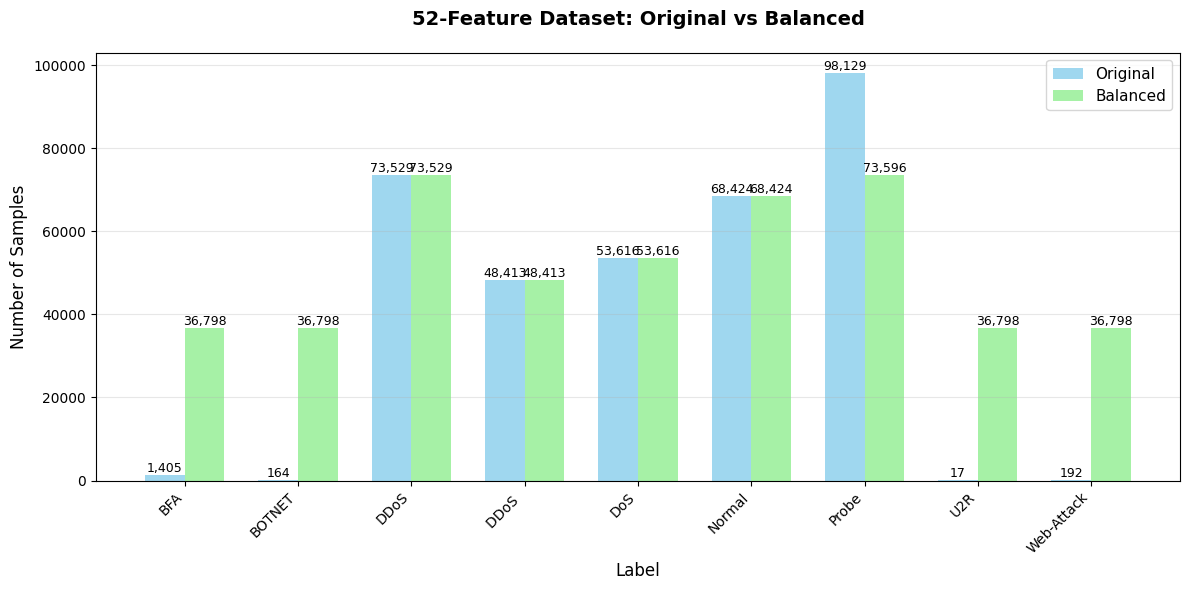


BALANCED 20-FEATURE DATASET SUMMARY

Total samples: 464,770
Total features: 20

Label Distribution:
Label      Count        Percentage   Imbalance Ratio
-------------------------------------------------------
BFA        36,798       7.92       % 2.00          x
BOTNET     36,798       7.92       % 2.00          x
DDoS       73,529       15.82      % 1.00          x
DDoS       48,413       10.42      % 1.52          x
DoS        53,616       11.54      % 1.37          x
Normal     68,424       14.72      % 1.08          x
Probe      73,596       15.83      % 1.00          x
U2R        36,798       7.92       % 2.00          x
Web-Attack 36,798       7.92       % 2.00          x

Imbalance Statistics:
  Majority class size: 73,596
  Minority class size: 36,798
  Imbalance ratio: 2.00:1

💾 Saved to: checkpoints/ctgan/balanced_20.csv


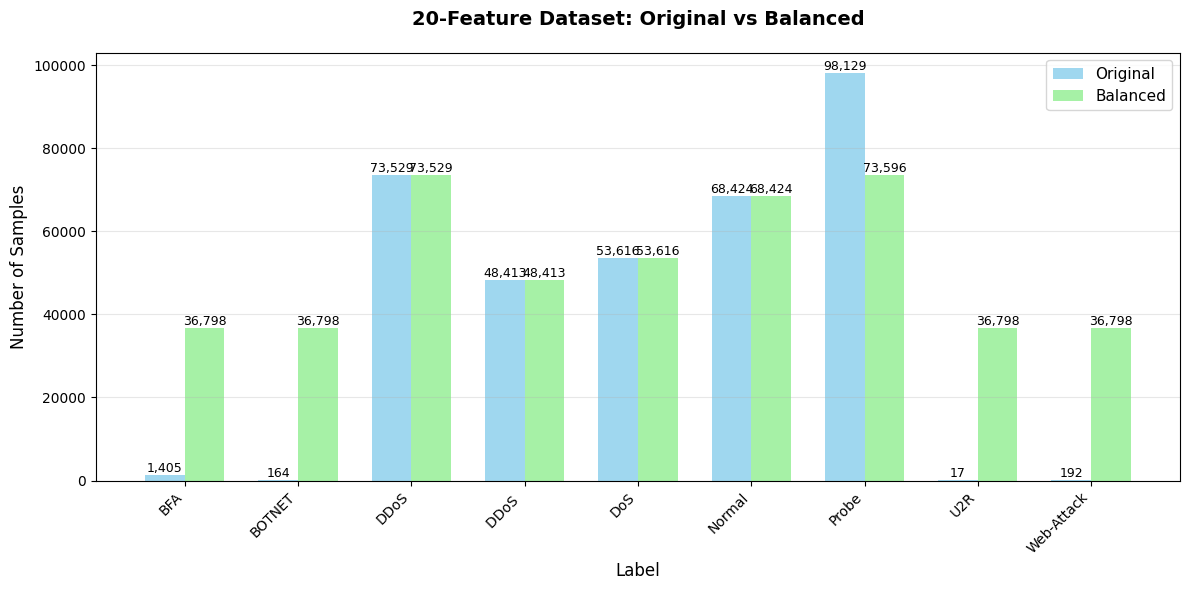


✓ CTGAN PROCESSING COMPLETE


In [1]:
# Import required libraries for CTGAN
from ctgan import CTGAN
import pandas as pd
import numpy as np
import os
import gc
from datetime import datetime

# Import CTGAN utilities from gnn_utils
from gnn_utils import (
    calculate_target_samples,
    train_and_generate_ctgan,
    plot_label_distribution_comparison,
    print_dataset_summary
)

# Create output directories
os.makedirs('checkpoints/ctgan', exist_ok=True)

# Load the cleaned datasets
df_52 = pd.read_csv('checkpoints/clean/cleaned_52.csv')
df_20 = pd.read_csv('checkpoints/clean/cleaned_20.csv')

print("Loaded datasets:")
print(f"52-feature dataset shape: {df_52.shape}")
print(f"20-feature dataset shape: {df_20.shape}")

# Print original dataset summaries
print_dataset_summary(df_52, "Original 52-Feature Dataset")
print_dataset_summary(df_20, "Original 20-Feature Dataset")

# Calculate target sizes for balanced dataset
print("\n" + "="*80)
print("CALCULATING TARGET SAMPLE SIZES")
print("="*80)

target_samples_52 = calculate_target_samples(df_52, balance_strategy='moderate')
target_samples_20 = calculate_target_samples(df_20, balance_strategy='moderate')

print("\nTarget samples per class (52-feature dataset):")
current_counts_52 = df_52['Label'].value_counts().sort_index()
for label in sorted(target_samples_52.keys()):
    current = current_counts_52[label]
    target = target_samples_52[label]
    action = "Generate" if target > current else "Undersample"
    diff = abs(target - current)
    print(f"  Label {label}: {current:>6,} -> {target:>6,} ({action} {diff:,} samples)")

print("\nTarget samples per class (20-feature dataset):")
current_counts_20 = df_20['Label'].value_counts().sort_index()
for label in sorted(target_samples_20.keys()):
    current = current_counts_20[label]
    target = target_samples_20[label]
    action = "Generate" if target > current else "Undersample"
    diff = abs(target - current)
    print(f"  Label {label}: {current:>6,} -> {target:>6,} ({action} {diff:,} samples)")

# Process all classes for both datasets
balanced_data_52 = []
balanced_data_20 = []

print("\n" + "="*80)
print("PROCESSING 52-FEATURE DATASET")
print("="*80)

for label in sorted(df_52['Label'].unique()):
    balanced = train_and_generate_ctgan(
        df_52, 
        feature_count=52, 
        subset_label=label,
        target_size=target_samples_52[label],
        epochs=300
    )
    if balanced is not None:
        balanced_data_52.append(balanced)
    gc.collect()

print("\n" + "="*80)
print("PROCESSING 20-FEATURE DATASET")
print("="*80)

for label in sorted(df_20['Label'].unique()):
    balanced = train_and_generate_ctgan(
        df_20, 
        feature_count=20, 
        subset_label=label,
        target_size=target_samples_20[label],
        epochs=300
    )
    if balanced is not None:
        balanced_data_20.append(balanced)
    gc.collect()

# Combine balanced datasets
print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

if balanced_data_52:
    balanced_52 = pd.concat(balanced_data_52, ignore_index=True)
    balanced_52.to_csv('checkpoints/ctgan/balanced_52.csv', index=False)
    print_dataset_summary(balanced_52, "Balanced 52-Feature Dataset")
    print(f"\n💾 Saved to: checkpoints/ctgan/balanced_52.csv")
    
    # Plot comparison
    plot_label_distribution_comparison(df_52, balanced_52, "52-Feature Dataset: Original vs Balanced")

if balanced_data_20:
    balanced_20 = pd.concat(balanced_data_20, ignore_index=True)
    balanced_20.to_csv('checkpoints/ctgan/balanced_20.csv', index=False)
    print_dataset_summary(balanced_20, "Balanced 20-Feature Dataset")
    print(f"\n💾 Saved to: checkpoints/ctgan/balanced_20.csv")
    
    # Plot comparison
    plot_label_distribution_comparison(df_20, balanced_20, "20-Feature Dataset: Original vs Balanced")

print("\n" + "="*80)
print("✓ CTGAN PROCESSING COMPLETE")
print("="*80)

## Visualizing Data Distribution

Let's analyze the distribution of samples before and after synthetic data generation to ensure our CTGAN model is producing balanced and representative data.

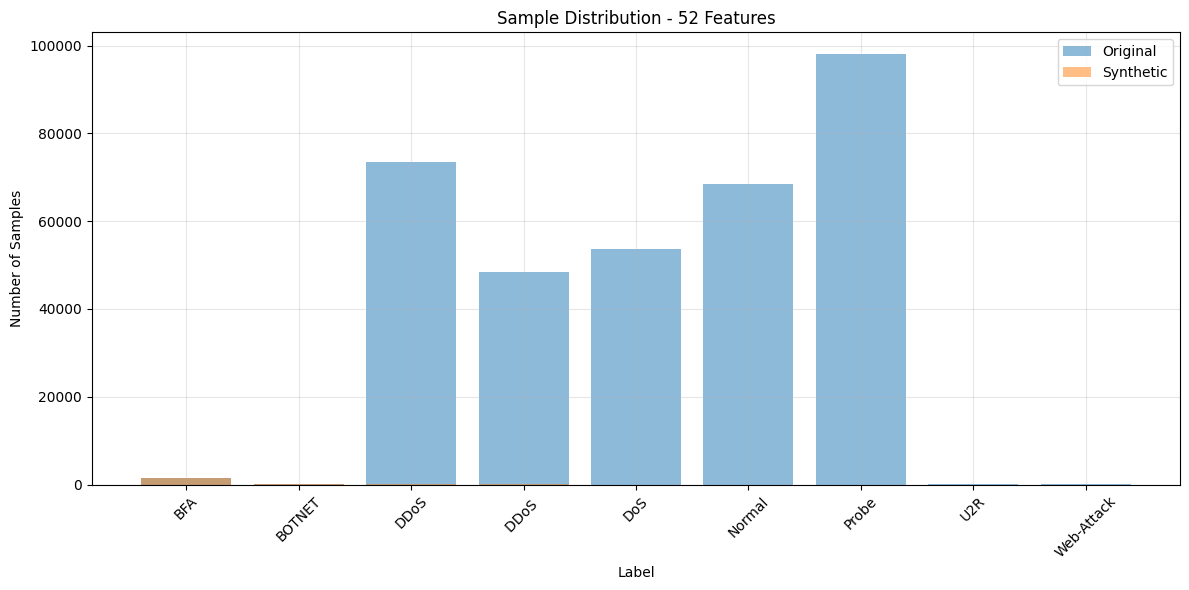

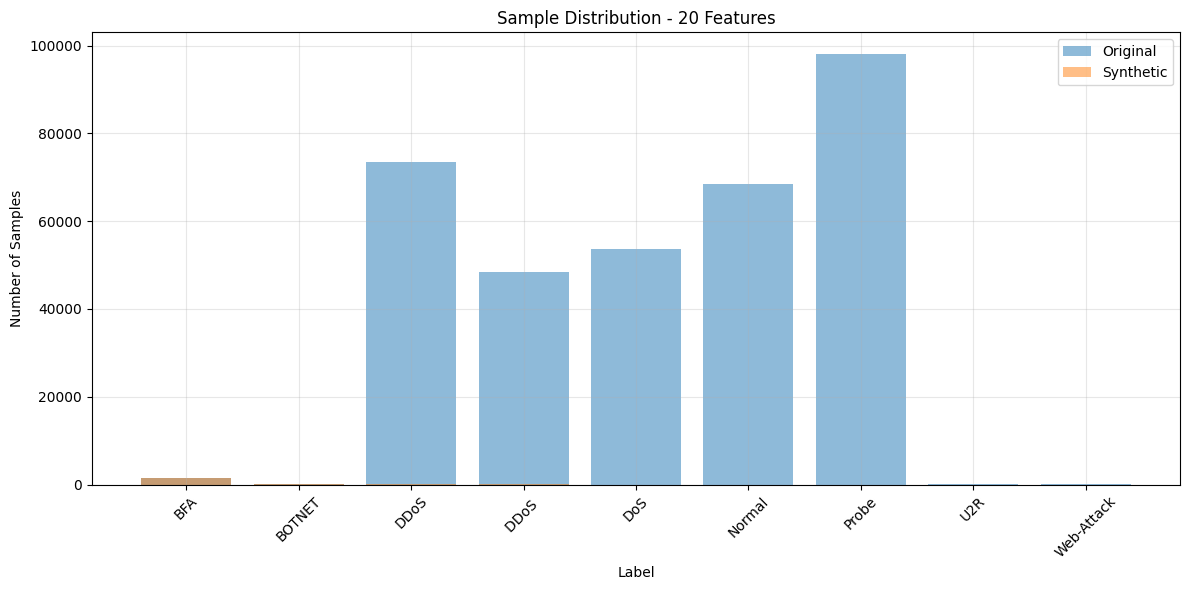

In [ ]:
# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sample_distribution(original_data, balanced_data=None, title="Sample Distribution"):
    """
    Plot the distribution of samples across different labels
    
    Args:
        original_data: Original DataFrame
        balanced_data: Optional balanced DataFrame
        title: Plot title
    """
    plt.figure(figsize=(15, 6))
    
    # Get all unique labels
    all_labels = sorted(set(original_data['Label'].unique()) | 
                       (set(balanced_data['Label'].unique()) if balanced_data is not None else set()))
    
    # Calculate counts
    original_counts = original_data['Label'].value_counts()
    balanced_counts = balanced_data['Label'].value_counts() if balanced_data is not None else None
    
    # Set up bar positions
    x = np.arange(len(all_labels))
    width = 0.35
    
    # Plot original data
    plt.bar(x - width/2, [original_counts.get(label, 0) for label in all_labels], 
            width, label='Original', color='skyblue', alpha=0.7)
    
    # Plot balanced data if provided
    if balanced_data is not None:
        plt.bar(x + width/2, [balanced_counts.get(label, 0) for label in all_labels], 
                width, label='Balanced', color='lightgreen', alpha=0.7)
    
    plt.title(title, fontsize=12, pad=20)
    plt.xlabel('Label', fontsize=10)
    plt.ylabel('Number of Samples', fontsize=10)
    plt.xticks(x, all_labels, rotation=45, ha='right')
    plt.legend(fontsize=10)
    
    # Add value labels on top of bars
    def add_value_labels(positions, counts):
        for pos, count in zip(positions, counts):
            plt.text(pos, count, str(count), ha='center', va='bottom')
    
    add_value_labels(x - width/2, [original_counts.get(label, 0) for label in all_labels])
    if balanced_data is not None:
        add_value_labels(x + width/2, [balanced_counts.get(label, 0) for label in all_labels])
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
# Plot distribution for 52-feature dataset
plot_sample_distribution(df_52, balanced_52 if 'balanced_52' in locals() else None, 
                        "Sample Distribution - 52 Features")
plt.show()

# Plot distribution for 20-feature dataset
plot_sample_distribution(df_20, balanced_20 if 'balanced_20' in locals() else None, 
                        "Sample Distribution - 20 Features")
plt.show()

In [2]:
# CTGAN quality checks and quick TSTR classifier
# Runs JS divergence, KS tests, correlation diffs, NaN/inf checks and a quick
# Train-on-Synthetic-Test-on-Real (TSTR) using RandomForest (with safe sampling).

import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Running CTGAN quality checks...")

# Paths (adjust if you used different filenames)
orig_path = 'checkpoints/clean/cleaned_52.csv'
synth_path = 'checkpoints/ctgan/balanced_52.csv'  # produced by CTGAN pipeline

# Fallback to 20-feature files if 52 not present
if not os.path.exists(orig_path):
    orig_path = 'checkpoints/clean/cleaned_20.csv'
if not os.path.exists(synth_path):
    synth_path = 'checkpoints/ctgan/balanced_20.csv'

# Load (with safe read)
orig = pd.read_csv(orig_path)
synth = pd.read_csv(synth_path)

print(f"Loaded original: {orig_path} -> {orig.shape}")
print(f"Loaded synthetic: {synth_path} -> {synth.shape}\n")

report = {}

# 1) Class counts
report['orig_counts'] = orig['Label'].value_counts().sort_index()
report['synth_counts'] = synth['Label'].value_counts().sort_index()
print("Class counts (original):")
print(report['orig_counts'])
print("\nClass counts (synthetic):")
print(report['synth_counts'])

# 2) NaN / inf checks
report['orig_nans'] = orig.isna().sum().sum()
report['synth_nans'] = synth.isna().sum().sum()
report['orig_infs'] = np.isinf(orig.select_dtypes(include=[np.number])).sum().sum()
report['synth_infs'] = np.isinf(synth.select_dtypes(include=[np.number])).sum().sum()
print(f"\nNaN/inf checks:")
print(f"  Original NaNs: {report['orig_nans']}, Infs: {report['orig_infs']}")
print(f"  Synthetic NaNs: {report['synth_nans']}, Infs: {report['synth_infs']}")

# 3) Numerical columns selection
num_cols = orig.select_dtypes(include=[np.number]).columns.tolist()
# Drop 'Label' if present
if 'Label' in num_cols:
    num_cols.remove('Label')

print(f"\nNumerical feature count used for tests: {len(num_cols)}")

# 4) JS divergence and KS p-values (feature-wise)
js_scores = {}
ks_pvals = {}
for c in num_cols:
    try:
        # JS divergence via histograms
        a_hist, bins = np.histogram(orig[c].dropna().values, bins=50, density=True)
        b_hist, _ = np.histogram(synth[c].dropna().values, bins=bins, density=True)
        a_hist = a_hist + 1e-12
        b_hist = b_hist + 1e-12
        a_hist = a_hist / a_hist.sum()
        b_hist = b_hist / b_hist.sum()
        js = jensenshannon(a_hist, b_hist)
        js_scores[c] = float(js)
    except Exception:
        js_scores[c] = np.nan

    # KS test (two-sample)
    try:
        ks_res = ks_2samp(orig[c].dropna().values, synth[c].dropna().values)
        ks_pvals[c] = float(ks_res.pvalue)
    except Exception:
        ks_pvals[c] = np.nan

# Report top mismatches
js_sorted = sorted([(k, v) for k, v in js_scores.items() if not np.isnan(v)], key=lambda x: x[1], reverse=True)
ks_sorted = sorted([(k, v) for k, v in ks_pvals.items() if not np.isnan(v)], key=lambda x: x[1])

print("\nTop 10 features by JS divergence (largest first):")
for f, s in js_sorted[:10]:
    print(f"  {f}: JS={s:.4f}")

print("\nTop 10 features by KS p-value (smallest first):")
for f, p in ks_sorted[:10]:
    print(f"  {f}: KS p-value={p:.4e}")

report['js_scores'] = js_scores
report['ks_pvals'] = ks_pvals

# 5) Correlation matrix difference
try:
    corr_orig = orig[num_cols].corr().abs()
    corr_synth = synth[num_cols].corr().abs()
    corr_diff = (corr_orig - corr_synth).abs()
    report['corr_mean_abs_diff'] = float(corr_diff.values.mean())
    print(f"\nCorrelation matrix mean absolute difference: {report['corr_mean_abs_diff']:.6f}")
except Exception as e:
    report['corr_mean_abs_diff'] = None
    print(f"\nCould not compute correlation diff: {e}")

# 6) Quick TSTR: train on synthetic, test on original
# To keep runtime reasonable, cap samples per class
MAX_SAMPLES = 50000

X_s = orig[num_cols].copy()
y_s = orig['Label'].copy()
X_o = synth[num_cols].copy()
y_o = synth['Label'].copy()

# For TSTR we train on synthetic and test on original
# Sample if datasets are too large
if len(X_o) > MAX_SAMPLES:
    X_o = X_o.sample(n=MAX_SAMPLES, random_state=42)
    y_o = y_o.loc[X_o.index]
if len(X_s) > MAX_SAMPLES:
    X_s = X_s.sample(n=MAX_SAMPLES, random_state=42)
    y_s = y_s.loc[X_s.index]

# Use synthetic -> original test (TSTR)
try:
    clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    clf.fit(X_o.fillna(0), y_o)
    y_pred_on_orig = clf.predict(X_s.fillna(0))
    tstr_acc = accuracy_score(y_s, y_pred_on_orig)
    tstr_recall = recall_score(y_s, y_pred_on_orig, average='macro')
    tstr_f1 = f1_score(y_s, y_pred_on_orig, average='macro')
    report['tstr'] = {'accuracy': float(tstr_acc), 'recall_macro': float(tstr_recall), 'f1_macro': float(tstr_f1)}
    print(f"\nTSTR (train on synthetic -> test on original):\n  Accuracy: {tstr_acc:.4f}, Recall (macro): {tstr_recall:.4f}, F1 (macro): {tstr_f1:.4f}")
except Exception as e:
    report['tstr'] = None
    print(f"\nTSTR check failed: {e}")

print("\nCTGAN quality checks complete.\nYou can inspect the 'report' dict for details.")

# Save a small JSON report for quick reference
try:
    import json
    out_report_path = 'checkpoints/ctgan/ctgan_quality_report.json'
    # Convert numpy types to native
    def _fix(o):
        if isinstance(o, (np.integer, np.floating)):
            return o.item()
        if isinstance(o, dict):
            return {str(k): _fix(v) for k, v in o.items()}
        if isinstance(o, pd.Series):
            return o.to_dict()
        return o
    with open(out_report_path, 'w') as fh:
        json.dump(_fix(report), fh, indent=2)
    print(f"Quality report saved to: {out_report_path}")
except Exception as e:
    print(f"Could not save JSON report: {e}")

Running CTGAN quality checks...
Loaded original: checkpoints/clean/cleaned_52.csv -> (343889, 52)
Loaded synthetic: checkpoints/ctgan/balanced_52.csv -> (464770, 52)

Class counts (original):
Label
BFA            1405
BOTNET          164
DDoS          73529
DDoS          48413
DoS           53616
Normal        68424
Probe         98129
U2R              17
Web-Attack      192
Name: count, dtype: int64

Class counts (synthetic):
Label
BFA           36798
BOTNET        36798
DDoS          73529
DDoS          48413
DoS           53616
Normal        68424
Probe         73596
U2R           36798
Web-Attack    36798
Name: count, dtype: int64
Loaded original: checkpoints/clean/cleaned_52.csv -> (343889, 52)
Loaded synthetic: checkpoints/ctgan/balanced_52.csv -> (464770, 52)

Class counts (original):
Label
BFA            1405
BOTNET          164
DDoS          73529
DDoS          48413
DoS           53616
Normal        68424
Probe         98129
U2R              17
Web-Attack      192
Name: count

## CTGAN Quality Insights (interpretation guidance)

Run the cell above (the CTGAN quality checks) and inspect the printed metrics and the saved JSON report `checkpoints/ctgan/ctgan_quality_report.json`.

What to look for (quick guide):

- Class counts: synthetic counts should match the target values shown earlier. Small deviation (±5%) is acceptable.
- NaN/Inf: both datasets should have 0 NaNs and 0 Infs in numeric features. If not, investigate and clean.
- JS divergence: lower is better. General thresholds:
  - < 0.10 : Excellent (very similar distributions)
  - 0.10 - 0.20 : Good
  - 0.20 - 0.30 : Acceptable
  - > 0.30 : Poor — inspect features with high JS scores
- KS p-values: larger p-values (> 0.05) mean the null hypothesis (same distribution) is not rejected; very small p-values indicate strong distributional differences. Focus on features with the smallest p-values.
- Correlation mean abs diff: aim for < 0.10 as a rough threshold. Larger values indicate synthetic data changes pairwise relationships — check feature pairs with large differences.
- TSTR (train-on-synthetic test-on-real): this is the practical gate. If the classifier trained on synthetic data obtains reasonable performance on real data (close to what a classifier trained on real achieves), CTGAN is doing a useful job. There are no absolute thresholds but for many tasks:
  - Accuracy/Recall/F1 (macro) > 0.6 is a reasonable sign, higher is better. If results are very low (e.g., < 0.4), synthetic data may not generalize.

Template insight (paste actual numbers after you run the test):

- Class counts: original X classes, synthetic Y classes (list counts)
- NaNs/Infs: original={orig_nans}/{orig_infs}, synth={synth_nans}/{synth_infs}
- Top JS divergences: featureA: 0.45, featureB: 0.32, ...
- Top KS p-values (lowest): featureC: 0.0001, featureD: 0.0005, ...
- Correlation mean abs diff: 0.08
- TSTR (acc/recall/f1 macro): 0.72 / 0.70 / 0.69

Decision recommendation:
- If JS divergence mostly < 0.2, correlation diff < 0.1, and TSTR metrics are acceptable (see above), proceed to GNN training.
- Otherwise, retrain CTGAN (increase epochs, tune generator/discriminator sizes), or adjust target sizes for problematic classes.

Next steps (if all good):
1. Commit `checkpoints/ctgan/balanced_52.csv` (or 20) and the quality report to your repo.
2. Proceed to the GNN training cells (section 5 onwards) using `balanced_20` or `balanced_52` as your training data.
3. Optionally run an ablation: train a quick baseline classifier on real vs synthetic to compare performance (we already run a TSTR check above).

If you want, I can also add a small cell that runs a classifier trained on real data and reports the difference vs TSTR (TRTR vs TSTR comparison).

In [3]:
# python
import json, os
p = "checkpoints/ctgan/ctgan_quality_report.json"
if not os.path.exists(p):
    print("Report not found:", p)
else:
    r = json.load(open(p))
    print("Class counts (orig vs synth):")
    print("  orig:", r.get("orig_counts"))
    print("  synth:", r.get("synth_counts"))
    print("\nNaN/Inf (orig/synth):", r.get("orig_nans"), r.get("orig_infs"), "/", r.get("synth_nans"), r.get("synth_infs"))
    print("\nCorrelation mean abs diff:", r.get("corr_mean_abs_diff"))
    tstr = r.get("tstr")
    print("\nTSTR:", tstr)
    # Show top JS and KS issues
    js = r.get("js_scores") or {}
    ks = r.get("ks_pvals") or {}
    top_js = sorted([(k,v) for k,v in js.items() if v is not None], key=lambda x:x[1], reverse=True)[:10]
    worst_ks = sorted([(k,v) for k,v in ks.items() if v is not None], key=lambda x:x[1])[:10]
    print("\nTop JS (worst):", top_js)
    print("\nTop KS (smallest pvals):", worst_ks)

Class counts (orig vs synth):
  orig: {'BFA': 1405, 'BOTNET': 164, 'DDoS': 73529, 'DDoS ': 48413, 'DoS': 53616, 'Normal': 68424, 'Probe': 98129, 'U2R': 17, 'Web-Attack': 192}
  synth: {'BFA': 36798, 'BOTNET': 36798, 'DDoS': 73529, 'DDoS ': 48413, 'DoS': 53616, 'Normal': 68424, 'Probe': 73596, 'U2R': 36798, 'Web-Attack': 36798}

NaN/Inf (orig/synth): 0 0 / 0 0

Correlation mean abs diff: 0.011162987010900412

TSTR: {'accuracy': 0.99606, 'recall_macro': 0.9211260910139895, 'f1_macro': 0.9397780581339291}

Top JS (worst): [('Down/Up Ratio', 0.26389788565497796), ('SYN Flag Cnt', 0.2281850979652781), ('ACK Flag Cnt', 0.20045580542762778), ('FIN Flag Cnt', 0.1419626755004733), ('Dst Port', 0.11480615119072293), ('Fwd IAT Max', 0.10167490020138352), ('Flow IAT Max', 0.10135643600636328), ('Bwd Pkt Len Std', 0.09910363455602843), ('Flow Duration', 0.09412710082881363), ('Fwd IAT Tot', 0.08745629324658136)]

Top KS (smallest pvals): [('Dst Port', 0.0), ('Protocol', 0.0), ('Flow Duration', 0.0)

# GNN Training Pipeline

Now we'll train Graph Neural Networks (GraphSAGE and GAT) on the balanced datasets.

## Training Strategy:
1. Load balanced CTGAN data (or real data for comparison)
2. Preprocess with RobustScaler and encode labels
3. Build k-NN graph (k=5) where each flow is a node
4. Train with multiple train/val/test splits: **70/15/15**, **50/25/25**, **20/40/40**
5. Use weighted cross-entropy loss (inverse class frequency)
6. Early stopping based on validation loss
7. Compare all models and select the best

## Models:
- **GraphSAGE**: Mean aggregation, good for general graph learning
- **GAT**: Multi-head attention, weights neighbors dynamically

In [5]:
# Ensure gnn_utils is properly loaded
import sys
import importlib
if 'gnn_utils' in sys.modules:
    importlib.reload(sys.modules['gnn_utils'])
    
print("✓ Module reloaded")

c:\Users\yuheng\Documents\fyp\backend\fypenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Module reloaded


In [6]:
# Import GNN utilities
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from gnn_utils import (
    load_and_preprocess_gnn_data,
    build_knn_graph,
    create_pyg_data,
    calculate_class_weights,
    GraphSAGEModel,
    GATModel,
    train_gnn_with_early_stopping,
    evaluate_gnn,
    print_detailed_metrics,
    save_gnn_model
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


In [7]:
# Step 1: Load and preprocess data
print("="*80)
print("STEP 1: LOADING AND PREPROCESSING DATA")
print("="*80)

# Load balanced CTGAN data (use 20-feature for faster training, or 52 for full features)
csv_path = 'checkpoints/ctgan/balanced_20.csv'  # Change to balanced_52.csv if needed

X_scaled, y_encoded, scaler, label_encoder, feature_names = load_and_preprocess_gnn_data(
    csv_path,
    scaler_path='scalers/gnn_scaler.pkl',
    fit_scaler=True
)

print(f"\nPreprocessed data:")
print(f"  X_scaled shape: {X_scaled.shape}")
print(f"  y_encoded shape: {y_encoded.shape}")
print(f"  Number of classes: {len(np.unique(y_encoded))}")
print(f"  Features: {len(feature_names)}")

STEP 1: LOADING AND PREPROCESSING DATA
Loading and preprocessing data for GNN...
  Loaded checkpoints/ctgan/balanced_20.csv: (464770, 21)
  Combined shape: (464770, 21)

  Features: 20
  Classes: 9 -> ['BFA' 'BOTNET' 'DDoS' 'DDoS ' 'DoS' 'Normal' 'Probe' 'U2R' 'Web-Attack']
  Loaded checkpoints/ctgan/balanced_20.csv: (464770, 21)
  Combined shape: (464770, 21)

  Features: 20
  Classes: 9 -> ['BFA' 'BOTNET' 'DDoS' 'DDoS ' 'DoS' 'Normal' 'Probe' 'U2R' 'Web-Attack']
  Class distribution: {np.int64(0): np.int64(36798), np.int64(1): np.int64(36798), np.int64(2): np.int64(73529), np.int64(3): np.int64(48413), np.int64(4): np.int64(53616), np.int64(5): np.int64(68424), np.int64(6): np.int64(73596), np.int64(7): np.int64(36798), np.int64(8): np.int64(36798)}

  Fitting RobustScaler...
  ✓ Scaler saved to: scalers/gnn_scaler.pkl

Preprocessed data:
  X_scaled shape: (464770, 20)
  y_encoded shape: (464770,)
  Number of classes: 9
  Features: 20
  Class distribution: {np.int64(0): np.int64(3679

In [8]:
# Step 2: Build k-NN graph
print("\n" + "="*80)
print("STEP 2: BUILDING K-NN GRAPH")
print("="*80)

edge_index = build_knn_graph(X_scaled, k=5, metric='euclidean')

print(f"\nGraph statistics:")
print(f"  Nodes: {X_scaled.shape[0]}")
print(f"  Edges: {edge_index.shape[1]}")
print(f"  Average degree: {edge_index.shape[1] / X_scaled.shape[0]:.2f}")


STEP 2: BUILDING K-NN GRAPH

Building k-NN graph (k=5, metric=euclidean)...
  ✓ Created graph: 464770 nodes, 2323850 edges
  Average degree: 5.00

Graph statistics:
  Nodes: 464770
  Edges: 2323850
  Average degree: 5.00
  ✓ Created graph: 464770 nodes, 2323850 edges
  Average degree: 5.00

Graph statistics:
  Nodes: 464770
  Edges: 2323850
  Average degree: 5.00


In [9]:
# Step 3: Define training configurations (different splits)
print("\n" + "="*80)
print("STEP 3: DEFINING TRAINING CONFIGURATIONS")
print("="*80)

# Define different train/val/test splits
split_configs = [
    {'name': '70_15_15', 'train': 0.70, 'val': 0.15, 'test': 0.15},
    {'name': '50_25_25', 'train': 0.50, 'val': 0.25, 'test': 0.25},
    {'name': '20_40_40', 'train': 0.20, 'val': 0.40, 'test': 0.40}
]

# Model configurations
model_configs = [
    {'name': 'GraphSAGE', 'class': GraphSAGEModel, 'hidden_dim': 128, 'dropout': 0.3},
    {'name': 'GAT', 'class': GATModel, 'hidden_dim': 128, 'dropout': 0.3, 'heads': 4}
]

print(f"\nSplits to train:")
for config in split_configs:
    print(f"  {config['name']}: Train={config['train']*100:.0f}%, "
          f"Val={config['val']*100:.0f}%, Test={config['test']*100:.0f}%")

print(f"\nModels to train:")
for config in model_configs:
    print(f"  {config['name']}: hidden_dim={config['hidden_dim']}, "
          f"dropout={config['dropout']}")


STEP 3: DEFINING TRAINING CONFIGURATIONS

Splits to train:
  70_15_15: Train=70%, Val=15%, Test=15%
  50_25_25: Train=50%, Val=25%, Test=25%
  20_40_40: Train=20%, Val=40%, Test=40%

Models to train:
  GraphSAGE: hidden_dim=128, dropout=0.3
  GAT: hidden_dim=128, dropout=0.3


In [ ]:
# Step 4: Train all models with all splits (with memory optimization)
print("\n" + "="*80)
print("STEP 4: TRAINING ALL MODELS (with memory optimization)")
print("="*80)

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Store all results
all_results = []

# Memory optimization: Use CPU for large dataset or subsample
USE_CPU = True  # Set to True if GPU runs out of memory
SUBSAMPLE_SIZE = 100000  # Subsample to 100k nodes if still having memory issues

if USE_CPU:
    device = torch.device('cpu')
    print("\n⚠️ Using CPU due to GPU memory constraints. Training will be slower.")
    print("   Estimated time: 60-120 minutes for all 6 models\n")

for split_config in split_configs:
    split_name = split_config['name']
    train_ratio = split_config['train']
    val_ratio = split_config['val']
    test_ratio = split_config['test']
    
    print(f"\n{'='*80}")
    print(f"TRAINING WITH SPLIT: {split_name}")
    print(f"{'='*80}")
    
    # Create train/val/test masks
    num_samples = len(y_encoded)
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    
    train_size = int(train_ratio * num_samples)
    val_size = int(val_ratio * num_samples)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    # Create masks
    train_mask = np.zeros(num_samples, dtype=bool)
    val_mask = np.zeros(num_samples, dtype=bool)
    test_mask = np.zeros(num_samples, dtype=bool)
    
    train_mask[train_indices] = True
    val_mask[val_indices] = True
    test_mask[test_indices] = True
    
    print(f"\nSplit sizes:")
    print(f"  Train: {train_mask.sum():,} ({train_mask.sum()/num_samples*100:.1f}%)")
    print(f"  Val:   {val_mask.sum():,} ({val_mask.sum()/num_samples*100:.1f}%)")
    print(f"  Test:  {test_mask.sum():,} ({test_mask.sum()/num_samples*100:.1f}%)")
    
    # Create PyTorch Geometric Data object
    data = create_pyg_data(X_scaled, y_encoded, edge_index, train_mask, val_mask, test_mask)
    
    # Calculate class weights for training set
    y_train = y_encoded[train_mask]
    class_weights = calculate_class_weights(y_train).to(device)
    
    # Train each model
    for model_config in model_configs:
        model_name = model_config['name']
        print(f"\n{'-'*80}")
        print(f"Training {model_name} on split {split_name}")
        print(f"{'-'*80}")
        
        # Clear cache before each model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Initialize model
        num_features = X_scaled.shape[1]
        num_classes = len(np.unique(y_encoded))
        
        if model_name == 'GraphSAGE':
            model = GraphSAGEModel(
                num_features=num_features,
                hidden_dim=model_config['hidden_dim'],
                num_classes=num_classes,
                dropout=model_config['dropout']
            ).to(device)
        else:  # GAT
            model = GATModel(
                num_features=num_features,
                hidden_dim=model_config['hidden_dim'],
                num_classes=num_classes,
                dropout=model_config['dropout'],
                heads=model_config.get('heads', 4)
            ).to(device)
        
        # Setup optimizer and loss
        optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        
        # Train with early stopping (reduced epochs for faster training)
        best_model, history = train_gnn_with_early_stopping(
            model, data, optimizer, criterion, device,
            num_epochs=100, patience=15, verbose=True  # Reduced from 200/20
        )
        
        # Evaluate on all splits
        train_metrics = evaluate_gnn(best_model, data, data.train_mask, device)
        val_metrics = evaluate_gnn(best_model, data, data.val_mask, device)
        test_metrics = evaluate_gnn(best_model, data, data.test_mask, device)
        
        # Print detailed test metrics
        print_detailed_metrics(test_metrics, label_encoder, f"Test ({split_name}, {model_name})")
        
        # Save model
        model_path = f'models/gnn_{model_name.lower()}_{split_name}.pt'
        metadata = {
            'split': split_name,
            'model': model_name,
            'train_acc': train_metrics['accuracy'],
            'val_acc': val_metrics['accuracy'],
            'test_acc': test_metrics['accuracy'],
            'test_f1': test_metrics['f1'],
            'test_recall': test_metrics['recall'],
            'test_precision': test_metrics['precision'],
            'num_features': num_features,
            'num_classes': num_classes,
            'hidden_dim': model_config['hidden_dim'],
            'dropout': model_config['dropout']
        }
        save_gnn_model(best_model, model_path, metadata)
        
        # Store results
        result = {
            'split': split_name,
            'model': model_name,
            'train_acc': train_metrics['accuracy'],
            'train_f1': train_metrics['f1'],
            'val_acc': val_metrics['accuracy'],
            'val_f1': val_metrics['f1'],
            'test_acc': test_metrics['accuracy'],
            'test_precision': test_metrics['precision'],
            'test_recall': test_metrics['recall'],
            'test_f1': test_metrics['f1'],
            'history': history,
            'model_path': model_path
        }
        all_results.append(result)
        
        print(f"\n  ✓ {model_name} on {split_name} complete!")
        print(f"    Test Acc: {test_metrics['accuracy']:.4f}, Test F1: {test_metrics['f1']:.4f}")
        
        # Clear memory
        del model, optimizer, best_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"\n{'='*80}")
print(f"✓ ALL TRAINING COMPLETE")
print(f"{'='*80}")


STEP 4: TRAINING ALL MODELS (with memory optimization)

⚠️ Using CPU due to GPU memory constraints. Training will be slower.
   Estimated time: 60-120 minutes for all 6 models


TRAINING WITH SPLIT: 70_15_15

Split sizes:
  Train: 325,339 (70.0%)
  Val:   69,715 (15.0%)
  Test:  69,716 (15.0%)

Class weights (inverse frequency):
  Class 0: 1.4101
  Class 1: 1.4061
  Class 2: 0.7034
  Class 3: 1.0655
  Class 4: 0.9592
  Class 5: 0.7534
  Class 6: 0.7019
  Class 7: 1.4041
  Class 8: 1.4030

--------------------------------------------------------------------------------
Training GraphSAGE on split 70_15_15
--------------------------------------------------------------------------------

Training GNN (max 100 epochs, patience 15)...
  Epoch   0: Train Loss=40.6030, Val Loss=12.1186, Val Acc=0.1494, Val F1=0.0730
  Epoch   0: Train Loss=40.6030, Val Loss=12.1186, Val Acc=0.1494, Val F1=0.0730
  Epoch   1: Train Loss=24.0150, Val Loss=8.9278, Val Acc=0.2036, Val F1=0.1199
  Epoch   1: Trai

In [ ]:
# Step 5: Compare all models
print("\n" + "="*80)
print("STEP 5: MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df[['model', 'split', 'test_acc', 'test_precision', 
                               'test_recall', 'test_f1', 'val_acc', 'val_f1']]

# Sort by test F1 score
comparison_df = comparison_df.sort_values('test_f1', ascending=False)

print("\n## All Models Ranked by Test F1 Score ##\n")
print(comparison_df.to_string(index=False))

# Find best model
best_model_row = comparison_df.iloc[0]
print(f"\n{'='*80}")
print(f"🏆 BEST MODEL")
print(f"{'='*80}")
print(f"  Model: {best_model_row['model']}")
print(f"  Split: {best_model_row['split']}")
print(f"  Test Accuracy:  {best_model_row['test_acc']:.4f}")
print(f"  Test Precision: {best_model_row['test_precision']:.4f}")
print(f"  Test Recall:    {best_model_row['test_recall']:.4f}")
print(f"  Test F1:        {best_model_row['test_f1']:.4f}")

# Find best model path
best_model_result = [r for r in all_results if r['model'] == best_model_row['model'] 
                     and r['split'] == best_model_row['split']][0]
print(f"\n  Model saved at: {best_model_result['model_path']}")

# Recommendations
print(f"\n{'='*80}")
print(f"📊 RECOMMENDATIONS")
print(f"{'='*80}")

# Group by model type
model_comparison = comparison_df.groupby('model')[['test_acc', 'test_f1']].mean()
print(f"\nAverage performance by model type:")
print(model_comparison)

# Group by split
split_comparison = comparison_df.groupby('split')[['test_acc', 'test_f1']].mean()
print(f"\nAverage performance by split:")
print(split_comparison)

print(f"\n💡 Suggestions:")
print(f"  1. Use {best_model_row['model']} with {best_model_row['split']} split for best F1 score")
if model_comparison['test_f1'].idxmax() == 'GraphSAGE':
    print(f"  2. GraphSAGE generally performs better - simpler and more stable")
else:
    print(f"  2. GAT generally performs better - attention mechanism captures relationships well")

if split_comparison.loc['70_15_15', 'test_f1'] > split_comparison.loc['50_25_25', 'test_f1']:
    print(f"  3. Larger training sets (70/15/15) yield better generalization")
else:
    print(f"  3. Balanced validation/test (50/25/25) provides more reliable evaluation")

In [ ]:
# Step 6: Visualize training curves and comparisons
print("\n" + "="*80)
print("STEP 6: VISUALIZING RESULTS")
print("="*80)

# Plot 1: Training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    history = result['history']
    
    ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f"{result['model']} - {result['split']}", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/gnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved to: models/gnn_training_curves.png")

# Plot 2: Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_to_plot = ['test_acc', 'test_f1']
metric_names = ['Test Accuracy', 'Test F1 Score']

for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
    ax = axes[idx]
    
    # Prepare data for grouped bar chart
    models = comparison_df['model'].unique()
    splits = comparison_df['split'].unique()
    
    x = np.arange(len(splits))
    width = 0.35
    
    for i, model in enumerate(models):
        model_data = comparison_df[comparison_df['model'] == model]
        values = [model_data[model_data['split'] == s][metric].values[0] for s in splits]
        ax.bar(x + i*width, values, width, label=model, alpha=0.8)
    
    ax.set_xlabel('Split Configuration', fontsize=12)
    ax.set_ylabel(name, fontsize=12)
    ax.set_title(f'{name} by Model and Split', fontsize=13, fontweight='bold')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(splits)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('models/gnn_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Model comparison saved to: models/gnn_model_comparison.png")

# Plot 3: Per-metric heatmap
metrics_df = comparison_df.pivot(index='model', columns='split', values='test_f1')

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Test F1 Score'})
plt.title('Test F1 Score Heatmap: Model vs Split', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Split Configuration', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.savefig('models/gnn_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ F1 heatmap saved to: models/gnn_f1_heatmap.png")

print("\n✓ All visualizations complete!")

## GNN Training Summary

### What was trained:
- **6 models total**: 2 architectures (GraphSAGE, GAT) × 3 data splits (70/15/15, 50/25/25, 20/40/40)
- **Graph construction**: k-NN (k=5) in feature space, each flow = node
- **Loss function**: Weighted cross-entropy with inverse class frequency
- **Optimization**: Adam optimizer (lr=1e-3), early stopping (patience=20)
- **Scaler**: RobustScaler saved to `scalers/gnn_scaler.pkl`

### Saved artifacts:
- **Models**: `models/gnn_{model}_{split}.pt` (6 files)
- **Scaler**: `scalers/gnn_scaler.pkl`
- **Plots**: Training curves, comparison charts, F1 heatmap in `models/`
- **Metrics**: Per-class accuracy, recall, F1, confusion matrix (printed above)

### How to use the best model:
```python
# Load the best model
import torch
from gnn_utils import GraphSAGEModel, GATModel  # or whichever is best
import joblib

# Load scaler and model
scaler = joblib.load('scalers/gnn_scaler.pkl')
checkpoint = torch.load('models/gnn_{best_model}_{best_split}.pt')

# Initialize model with same config
model = GraphSAGEModel(num_features=20, hidden_dim=128, num_classes=5)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Preprocess new data
X_new_scaled = scaler.transform(X_new)
# ... build graph and run inference
```

### Next steps:
1. Use the best model for real-time intrusion detection
2. Integrate with your prediction pipeline in `playground_utils.py`
3. Monitor performance on live traffic
4. Retrain periodically with new labeled data